In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("hotel_bookings.csv")

In [17]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,NaN,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,NaN,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,NaN,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,NaN,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,NaN,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,NaN,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,NaN,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,NaN,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,NaN,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [18]:
df.shape

(119390, 32)

In [19]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,NaN,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,NaN,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,NaN,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,NaN,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,NaN,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [20]:
market_cancel=df.groupby("market_segment",as_index=False)["is_canceled"].mean()
market_cancel["cancellation_rate"]=market_cancel["is_canceled"]*100
print(market_cancel)

  market_segment  is_canceled  cancellation_rate
0       Aviation     0.219409          21.940928
1  Complementary     0.130552          13.055182
2      Corporate     0.187347          18.734655
3         Direct     0.153419          15.341901
4         Groups     0.610620          61.062036
5  Offline TA/TO     0.343160          34.316033
6      Online TA     0.367211          36.721143
7      Undefined     1.000000         100.000000


C:\Users\Dell\AppData\Local\Temp\ipykernel_26176\2394043159.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


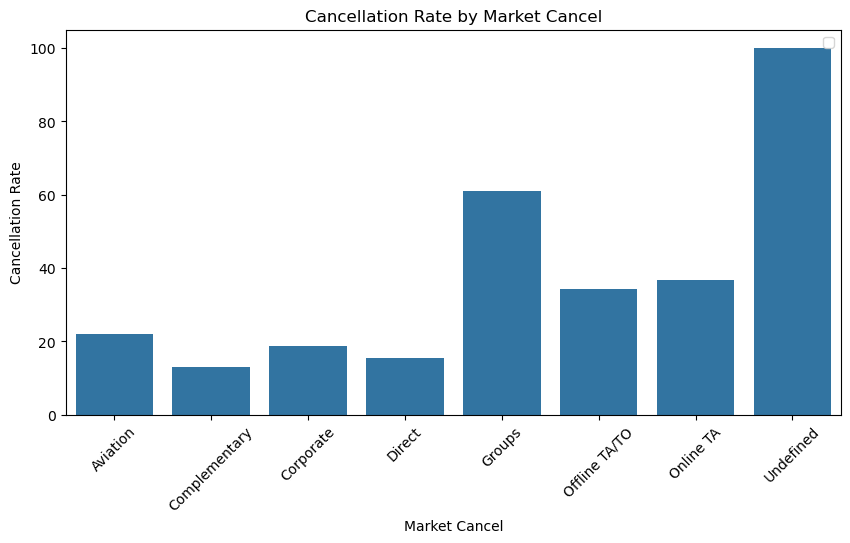

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=market_cancel,
    x="market_segment",
    y="cancellation_rate"
)        
plt.title("Cancellation Rate by Market Cancel")
plt.xlabel("Market Cancel")
plt.ylabel("Cancellation Rate")
plt.legend()
plt.xticks(rotation=45)
plt.show()     

          hotel  is_canceled  cancellation_rate
0    City Hotel     0.417270          41.726963
1  Resort Hotel     0.277634          27.763355


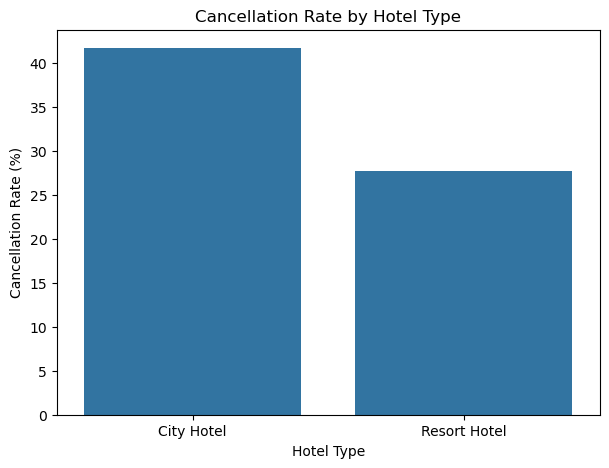

In [22]:
hotel_cancel=df.groupby("hotel", as_index=False)["is_canceled"].mean()
hotel_cancel["cancellation_rate"]=hotel_cancel["is_canceled"]*100
print(hotel_cancel)

plt.figure(figsize=(7,5))

sns.barplot(
    data=hotel_cancel,
    x="hotel",
    y="cancellation_rate"
)        
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()     

In [23]:
month_order= [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun", 
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=month_order,
    ordered=True
)
monthly_arrivals = df.groupby(
    "arrival_date_month",
    as_index=False,
    observed=True
).size()

monthly_arrivals.columns = ["month", "arrivals"]

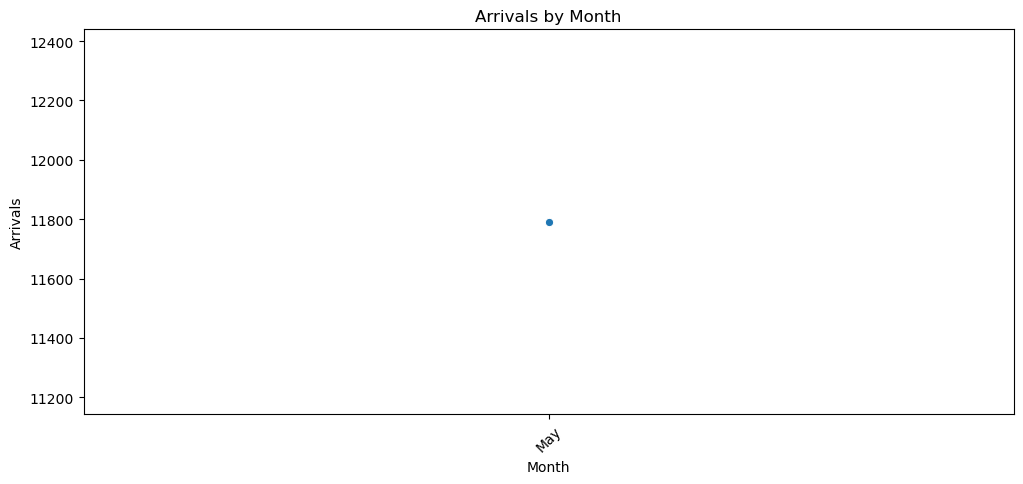

In [24]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_arrivals,
    x="month",
    y="arrivals",
    marker="o"
)
plt.title("Arrivals by Month")
plt.xlabel("Month")
plt.ylabel("Arrivals")
plt.xticks(rotation=45)

plt.show()

In [26]:
monthly_adr=df.groupby(
    "arrival_date_month",
    as_index=False,
    observed=True
)["adr"].mean()

monthly_adr.columns=["month","adr"]

In [27]:
monthly_adr

,month,adr
0,May,108.695516


In [25]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_adr,
    x="month",
    y="adr",
    marker="o"
)
plt.title("Monthly ADR Fluctuation")
plt.xlabel("Month")
plt.ylabel("Average Date Rate(%)")
plt.xticks(rotation=45)

plt.show()

NameError: name 'monthly_adr' is not defined

<Figure size 1200x500 with 0 Axes>

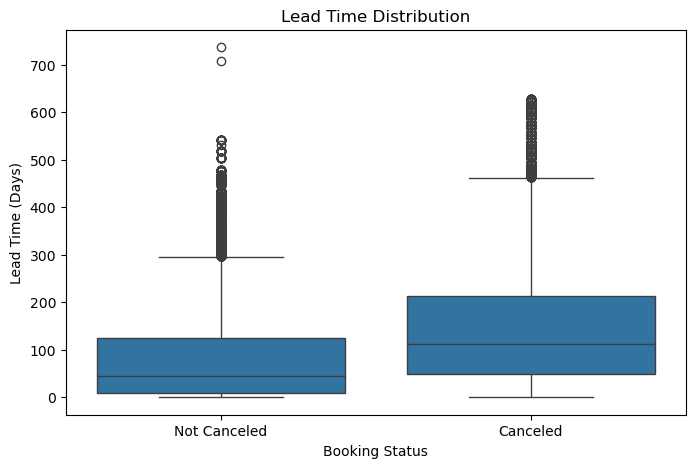

In [28]:
df["booking_status"] = df["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="booking_status",
    y="lead_time"
)

plt.title("Lead Time Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time (Days)")

plt.show()